Image Shape: (1000, 664, 3)


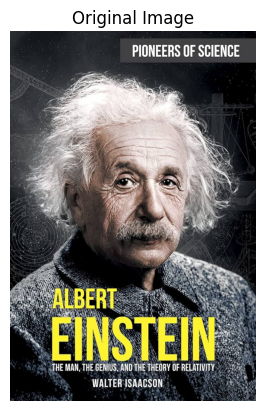

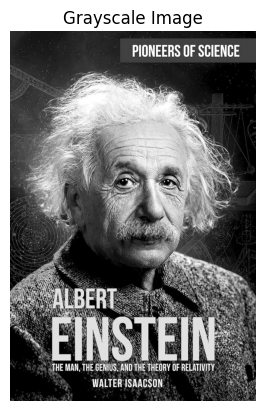

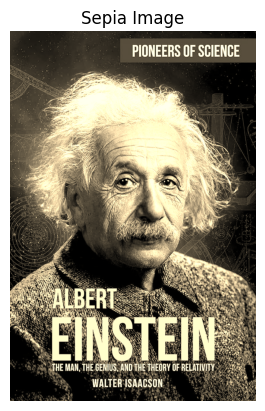

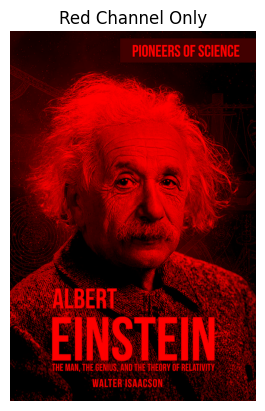

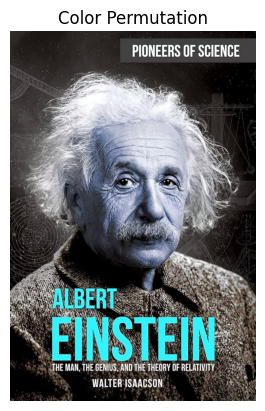

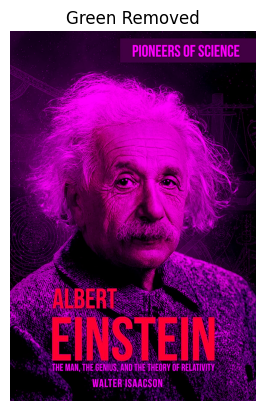

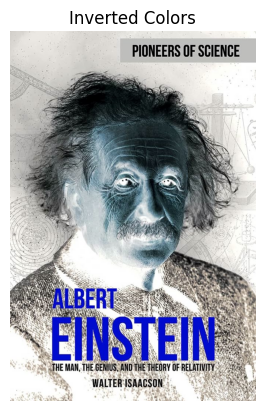

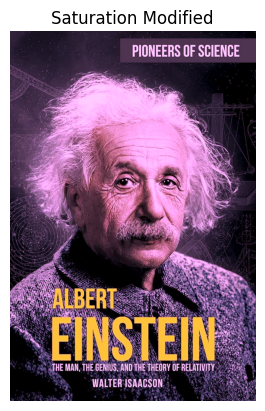

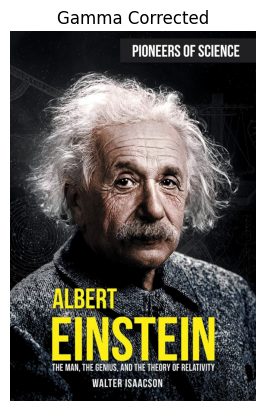

In [2]:
import numpy as np
import imageio.v3 as imageio
import matplotlib.pyplot as plt

image_path = "einstein.jpg"

# Load an image
def load_image(image_path):
    return imageio.imread(image_path)

# Display an image correctly
def display_image(image, title="Image"):
    plt.imshow(image, cmap="gray" if len(image.shape) == 2 else None)
    plt.title(title)
    plt.axis("off")
    plt.show()

# Extract image information
def get_image_info(image):
    return image.shape

# Convert to grayscale using matrix multiplication
def convert_to_grayscale(image):
    if len(image.shape) == 2:
        return image
    grayscale_weights = np.array([0.2989, 0.5870, 0.1140])
    reshaped_image = image.reshape(-1, 3)
    grayscale = np.dot(reshaped_image[:, :3], grayscale_weights)
    grayscale = grayscale.reshape(image.shape[0], image.shape[1])
    return grayscale.astype(np.uint8)

# Convert grayscale to RGB by repeating the values across 3 channels
def convert_to_rgb(image):
    if len(image.shape) == 2:
        return np.stack([image] * 3, axis=-1)
    return image

# Apply Sepia filter
def apply_sepia(image):
    image = convert_to_rgb(image)
    sepia_matrix = np.array([[0.393, 0.769, 0.189],
                             [0.349, 0.686, 0.168],
                             [0.272, 0.534, 0.131]])
    sepia_image = np.dot(image[..., :3], sepia_matrix.T)
    return np.clip(sepia_image, 0, 255).astype(np.uint8)

# Extract red channel
def extract_red_channel(image):
    image = convert_to_rgb(image)
    red_image = np.zeros_like(image)
    red_image[..., 0] = image[..., 0]
    return red_image

# Permute color channels (R -> B, B -> R, G stays the same)
def permute_colors(image):
    image = convert_to_rgb(image)
    return image[..., [2, 1, 0]]

# Remove green color
def remove_green(image):
    image = convert_to_rgb(image)
    no_green_image = image.copy()
    no_green_image[..., 1] = 0
    return no_green_image

# Invert image colors
def invert_colors(image):
    image = convert_to_rgb(image)
    return 255 - image

# Modify saturation
def modify_saturation(image, red_factor=1.2, blue_factor=1.2, green_factor=0.8):
    image = convert_to_rgb(image)
    saturated_image = image.copy().astype(np.float32)
    saturated_image[..., 0] *= red_factor
    saturated_image[..., 1] *= green_factor
    saturated_image[..., 2] *= blue_factor
    return np.clip(saturated_image, 0, 255).astype(np.uint8)

# User-defined color adjustment
def user_defined_adjustment(image, matrix):
    image = convert_to_rgb(image)  # Convert to RGB if grayscale
    adjusted_image = np.dot(image[..., :3], matrix.T)
    return np.clip(adjusted_image, 0, 255).astype(np.uint8)

# Compute inverse transformation
def inverse_transformation(image, matrix):
    image = convert_to_rgb(image)  # Convert to RGB if grayscale
    inverse_matrix = np.linalg.inv(matrix)
    restored_image = np.dot(image[..., :3], inverse_matrix.T)
    return np.clip(restored_image, 0, 255).astype(np.uint8)

# Apply Gamma Correction
def gamma_correction(image, gamma=1.0):
    image = convert_to_rgb(image)
    corrected_image = 255 * (image / 255) ** gamma
    return np.clip(corrected_image, 0, 255).astype(np.uint8)

# Example Usage
if __name__ == "__main__":
    img = load_image("einstein.jpg")
    print("Image Shape:", get_image_info(img))

    grayscale_img = convert_to_grayscale(img)
    sepia_img = apply_sepia(img)
    red_channel_img = extract_red_channel(img)
    permuted_img = permute_colors(img)
    no_green_img = remove_green(img)
    inverted_img = invert_colors(img)
    saturated_img = modify_saturation(img)
    gamma_img = gamma_correction(img, 1.5)

    display_image(img, "Original Image")
    display_image(grayscale_img, "Grayscale Image")
    display_image(sepia_img, "Sepia Image")
    display_image(red_channel_img, "Red Channel Only")
    display_image(permuted_img, "Color Permutation")
    display_image(no_green_img, "Green Removed")
    display_image(inverted_img, "Inverted Colors")
    display_image(saturated_img, "Saturation Modified")
    display_image(gamma_img, "Gamma Corrected")
